In [76]:
!pip install xgboost
!pip install lightgbm

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 5.3 MB/s eta 0:00:20
    --------------------------------------- 1.8/101.7 MB 4.5 MB/s eta 0:00:23
   - -------------------------------------- 2.6/101.7 MB 4.3 MB/s eta 0:00:24
   - -------------------------------------- 3.4/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 4.2/101.7 MB 4.1 MB/s eta 0:00:24
   - -------------------------------------- 5.0/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 6.0/101.7 MB 4.0 MB/s eta 0:00:24
   -- ------------------------------------- 6.8/101.7 MB 4.0 MB/s eta 0:00:24
   -- ------------------------------------- 7.6/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 8.4/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 9.2/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 10.0/101.7 MB 4.0 MB/s eta 


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 4.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
## read the data
data = pd.read_csv(r'C:\Users\sbadiger\AI_Practice_Excelr\datasets\sales.csv')
data.head()
data.columns

Index(['Unnamed: 0', 'CompPrice', 'Income', 'Advertising', 'Population',
       'Price', 'ShelveLoc', 'Age', 'Education', 'Urban', 'US', 'high'],
      dtype='object')

In [41]:
data = data.drop('Unnamed: 0', axis=1)
data.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,138,73,11,276,120,Bad,42,17,Yes,Yes,yes
1,111,48,16,260,83,Good,65,10,Yes,Yes,yes
2,113,35,10,269,80,Medium,59,12,Yes,Yes,yes
3,117,100,4,466,97,Medium,55,14,Yes,Yes,no
4,141,64,3,340,128,Bad,38,13,Yes,No,no


In [42]:
### Encode categorical data
from sklearn.preprocessing import LabelEncoder, StandardScaler
enc = LabelEncoder()
scaler = StandardScaler()
for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = enc.fit_transform(data[column])
    else:
        data[column] = scaler.fit_transform(data[[column]])
data.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,0.850455,0.155361,0.657177,0.075819,0.177823,0,-0.699782,1.184449,1,1,1
1,-0.912484,-0.739060,1.409957,-0.032882,-1.386854,1,0.721723,-1.490113,1,1,1
2,-0.781896,-1.204159,0.506621,0.028262,-1.513719,2,0.350895,-0.725953,1,1,1
3,-0.520720,1.121336,-0.396715,1.366649,-0.794814,2,0.103677,0.038208,1,1,0
4,1.046337,-0.166631,-0.547271,0.510625,0.516132,0,-0.947000,-0.343872,1,0,0


In [43]:
#### Split the data into train and test
from sklearn.model_selection import train_test_split
X = data.drop('high', axis=1)
y = data['high']

In [44]:
X.head(3)

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,0.850455,0.155361,0.657177,0.075819,0.177823,0,-0.699782,1.184449,1,1
1,-0.912484,-0.739060,1.409957,-0.032882,-1.386854,1,0.721723,-1.490113,1,1
2,-0.781896,-1.204159,0.506621,0.028262,-1.513719,2,0.350895,-0.725953,1,1


In [45]:
y.head(3)

0    1
1    1
2    1
Name: high, dtype: int64

In [46]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42) ### random state will help you keep same data everytime we run this code. same random set of value we ll get
X_train.shape,X_test.shape,y_train.shape,y_test.shape
                                                

((320, 10), (80, 10), (320,), (80,))

In [47]:
X_train.head()  ###it splits randomly

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
3,-0.520720,1.121336,-0.396715,1.366649,-0.794814,2,0.103677,0.038208,1,1
18,-0.977778,1.479105,-0.998939,0.972607,-2.021182,1,-0.452564,1.184449,0,1
202,-0.259544,0.334245,-0.396715,1.006576,0.600709,0,-0.452564,-1.490113,0,1
250,0.785161,1.300220,0.506621,1.156040,1.700212,1,1.154355,0.038208,1,1
274,0.654573,0.870898,-0.697827,-1.344094,0.135535,2,-1.194219,-1.108033,1,1


In [30]:
###Build the Model - Bagging model
#till certain point logistic regression is linear regression itself
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier



In [50]:
lreg = LogisticRegression(max_iter=400)
bagg_model = BaggingClassifier(estimator=lreg, n_estimators=100)

## Train the model using training data
bagg_model.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",LogisticRegre...(max_iter=400)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [52]:
### Evaluate the model
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

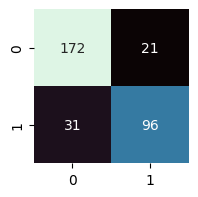

In [53]:
### Training data
yhat_train = bagg_model.predict(X_train)
cm = confusion_matrix(y_train, yhat_train)
cm
plt.figure(figsize=(2,2))
sns.heatmap(cm,annot=True,fmt='d',cbar=False,cmap='mako')
plt.show()

In [54]:
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       193
           1       0.82      0.76      0.79       127

    accuracy                           0.84       320
   macro avg       0.83      0.82      0.83       320
weighted avg       0.84      0.84      0.84       320



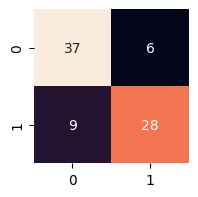

In [56]:
yhat_test = bagg_model.predict(X_test)
cm_test = confusion_matrix(y_test,yhat_test)
cm_test
plt.figure(figsize=(2,2))
sns.heatmap(cm_test,annot=True,fmt='d',cbar=False)
plt.show()

In [57]:
print(classification_report(y_test,yhat_test))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83        43
           1       0.82      0.76      0.79        37

    accuracy                           0.81        80
   macro avg       0.81      0.81      0.81        80
weighted avg       0.81      0.81      0.81        80



In [31]:
### This is a not even too bad and too good model.

In [59]:
def plot_roc(y,yhat):
   fpr,tpr,thresh = roc_curve(y,yhat)
   auc = roc_auc_score(y,yhat)
   print(f'AUC : {auc}')
   plt.figure(figsize=(3,3))

   plt.title('AUC - ROC curve ',fontsize=15)
   plt.xlabel('False Positive Rate(FPR)')
   plt.ylabel('True Positive Rate(TPR)')

   plt.plot(fpr,tpr)
   plt.plot([0,1],[0,1],'o--')
   plt.show()
   

AUC : 0.8235486108277916


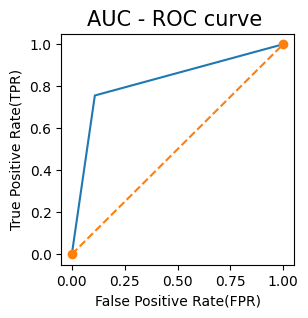

In [60]:
plot_roc(y_train,yhat_train)

AUC : 0.8086109365179133


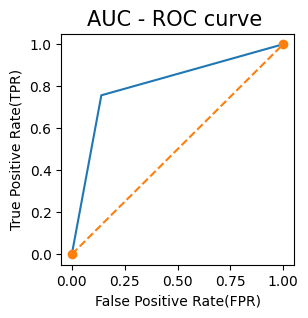

In [61]:
plot_roc(y_test,yhat_test)

In [62]:
#### b. Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=4, max_features=4)

## Train the model using training data
rf_model.fit(X_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",4
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true,

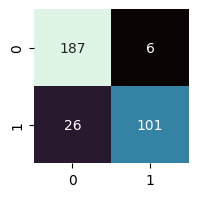

In [64]:
#### Split the data into train and test
yhat_train = rf_model.predict(X_train)
cm = confusion_matrix(y_train, yhat_train)
cm
plt.figure(figsize=(2,2))
sns.heatmap(cm,annot=True,fmt='d',cbar=False,cmap='mako')
plt.show()

In [65]:
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       193
           1       0.94      0.80      0.86       127

    accuracy                           0.90       320
   macro avg       0.91      0.88      0.89       320
weighted avg       0.90      0.90      0.90       320



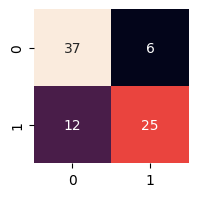

In [68]:
yhat_test = rf_model.predict(X_test)
cm_test = confusion_matrix(y_test,yhat_test)
cm_test
plt.figure(figsize=(2,2))
sns.heatmap(cm_test,annot=True,fmt='d',cbar=False)
plt.show()

In [69]:
print(classification_report(y_test,yhat_test))

              precision    recall  f1-score   support

           0       0.76      0.86      0.80        43
           1       0.81      0.68      0.74        37

    accuracy                           0.78        80
   macro avg       0.78      0.77      0.77        80
weighted avg       0.78      0.78      0.77        80



In [70]:
######### c. AdaBoost
from sklearn.ensemble import AdaBoostClassifier
ada_model = AdaBoostClassifier(n_estimators=100)

## Train the model using training data
ada_model.fit(X_train,y_train)



,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


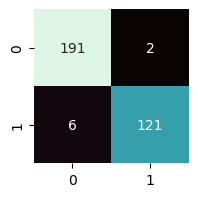

In [71]:
#### Split the data into train and test
yhat_train = ada_model.predict(X_train)
cm = confusion_matrix(y_train, yhat_train)
cm
plt.figure(figsize=(2,2))
sns.heatmap(cm,annot=True,fmt='d',cbar=False,cmap='mako')
plt.show()

In [72]:
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       193
           1       0.98      0.95      0.97       127

    accuracy                           0.97       320
   macro avg       0.98      0.97      0.97       320
weighted avg       0.98      0.97      0.97       320



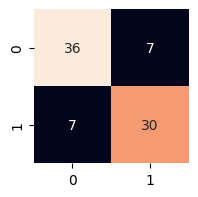

In [73]:
yhat_test = ada_model.predict(X_test)
cm_test = confusion_matrix(y_test,yhat_test)
cm_test
plt.figure(figsize=(2,2))
sns.heatmap(cm_test,annot=True,fmt='d',cbar=False)
plt.show()

In [74]:
print(classification_report(y_test,yhat_test))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84        43
           1       0.81      0.81      0.81        37

    accuracy                           0.82        80
   macro avg       0.82      0.82      0.82        80
weighted avg       0.82      0.82      0.82        80

